# Analysis Notebook

# Setup

In [ ]:
#| label: setup
#| include: false

options(warn = -1)

packages <- c("multcomp","DT","car","glmmTMB","AICcmodavg", "ggeffects","DHARMa", "brms", "emmeans", "lme4","lmerTest","vegan","ggnewscale","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

# Load packages if not already installed
quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

exc_file_dir <- "data/raw/NCE_data.xlsx"
der_data_dir <- "data/derived"
out_dir      <- "outputs"

# Read sheets from raw xlsx
df_NCE_raw <- readxl::read_excel(exc_file_dir, sheet = "NCE_exp")
df_Feeding_raw <- readxl::read_excel(exc_file_dir, sheet = "Feeding")

# Save as csv to derived/
write.csv(df_NCE_raw,     file.path(der_data_dir, "NCE_exp.csv"),  row.names = FALSE)
write.csv(df_Feeding_raw, file.path(der_data_dir, "Feeding.csv"),  row.names = FALSE)

df_NCE_raw     <- read.csv(file.path(der_data_dir, "NCE_exp.csv"))
df_Feeding_raw <- read.csv(file.path(der_data_dir, "Feeding.csv"))

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "sans", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

# Refuge experiment

## Build refuge dataframe

In [ ]:
#| label: build-df
#| include: false

df_NCE_raw <- df_NCE_raw %>%
  dplyr::select(-location_T180, -behaviour_T180)

# make into long format
koura_long <- df_NCE_raw %>%
  pivot_longer(
    cols = matches("^(location|behaviour)_"),
    names_to   = c(".value","time"),
    names_pattern = "(location|behaviour)_T?(\\d+)" ) %>%
  mutate(time = as.numeric(time))

koura_long <- koura_long %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

#Group all refuge used
koura_long_ref <- koura_long %>%
  mutate(
    location = case_when(
      location %in% c("floor", "wall", "barrier") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_))

koura_long_ref <- koura_long_ref %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

## Refuge table

In [ ]:
#| label: tbl-s1-refuge-prop
#| include: true
#| tbl-cap: "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge."

prop_refuge_light_treat <- koura_long_ref %>%
  dplyr::group_by(light, treatment, period) %>%
  dplyr::summarise(
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_treat <- koura_long_ref %>%
  dplyr::group_by(treatment, period) %>%
  dplyr::summarise(light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_light <- koura_long_ref %>%
  dplyr::group_by(light, period) %>%
  dplyr::summarise(treatment = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_per <- koura_long_ref %>%
  dplyr::group_by(period) %>%
  dplyr::summarise(treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_comb <- koura_long_ref %>%
  dplyr::summarise(period = "combined",
    treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

refuge_table <- dplyr::bind_rows(prop_refuge_light_treat, prop_refuge_treat,prop_refuge_light, prop_refuge_per, prop_refuge_comb) %>%
  mutate_if(is.numeric, round, digits = 2)

# extract specific values for inline reporting
get_prop <- function(l, t, p) {
  refuge_table %>% 
    filter(light == l, treatment == t, period == p) %>% 
    pull(prop_refuge)
}

write.csv(refuge_table, file = file.path(out_dir, "refuge_table.csv"), row.names = FALSE)

if (knitr::is_html_output()) {
  datatable(
    refuge_table,
    caption = "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge.",
    filter = "top",
    options = list(
      pageLength = 37,
      dom = 'Bfrtip',
      buttons = c('csv', 'excel'),
      columnDefs = list(list(className = 'dt-center', targets = "_all"))
    ),
    extensions = 'Buttons',
    rownames = FALSE,
    colnames = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
  ) |>
    formatRound(columns = "prop_refuge", digits = 2) |>
    formatStyle(
      "prop_refuge",
      background = styleColorBar(range(refuge_table$prop_refuge), "lightblue"),
      backgroundSize = "100% 90%",
      backgroundRepeat = "no-repeat",
      backgroundPosition = "center"
    )
} else {
  knitr::kable(refuge_table, digits = 2)
}

## Refuge plot

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

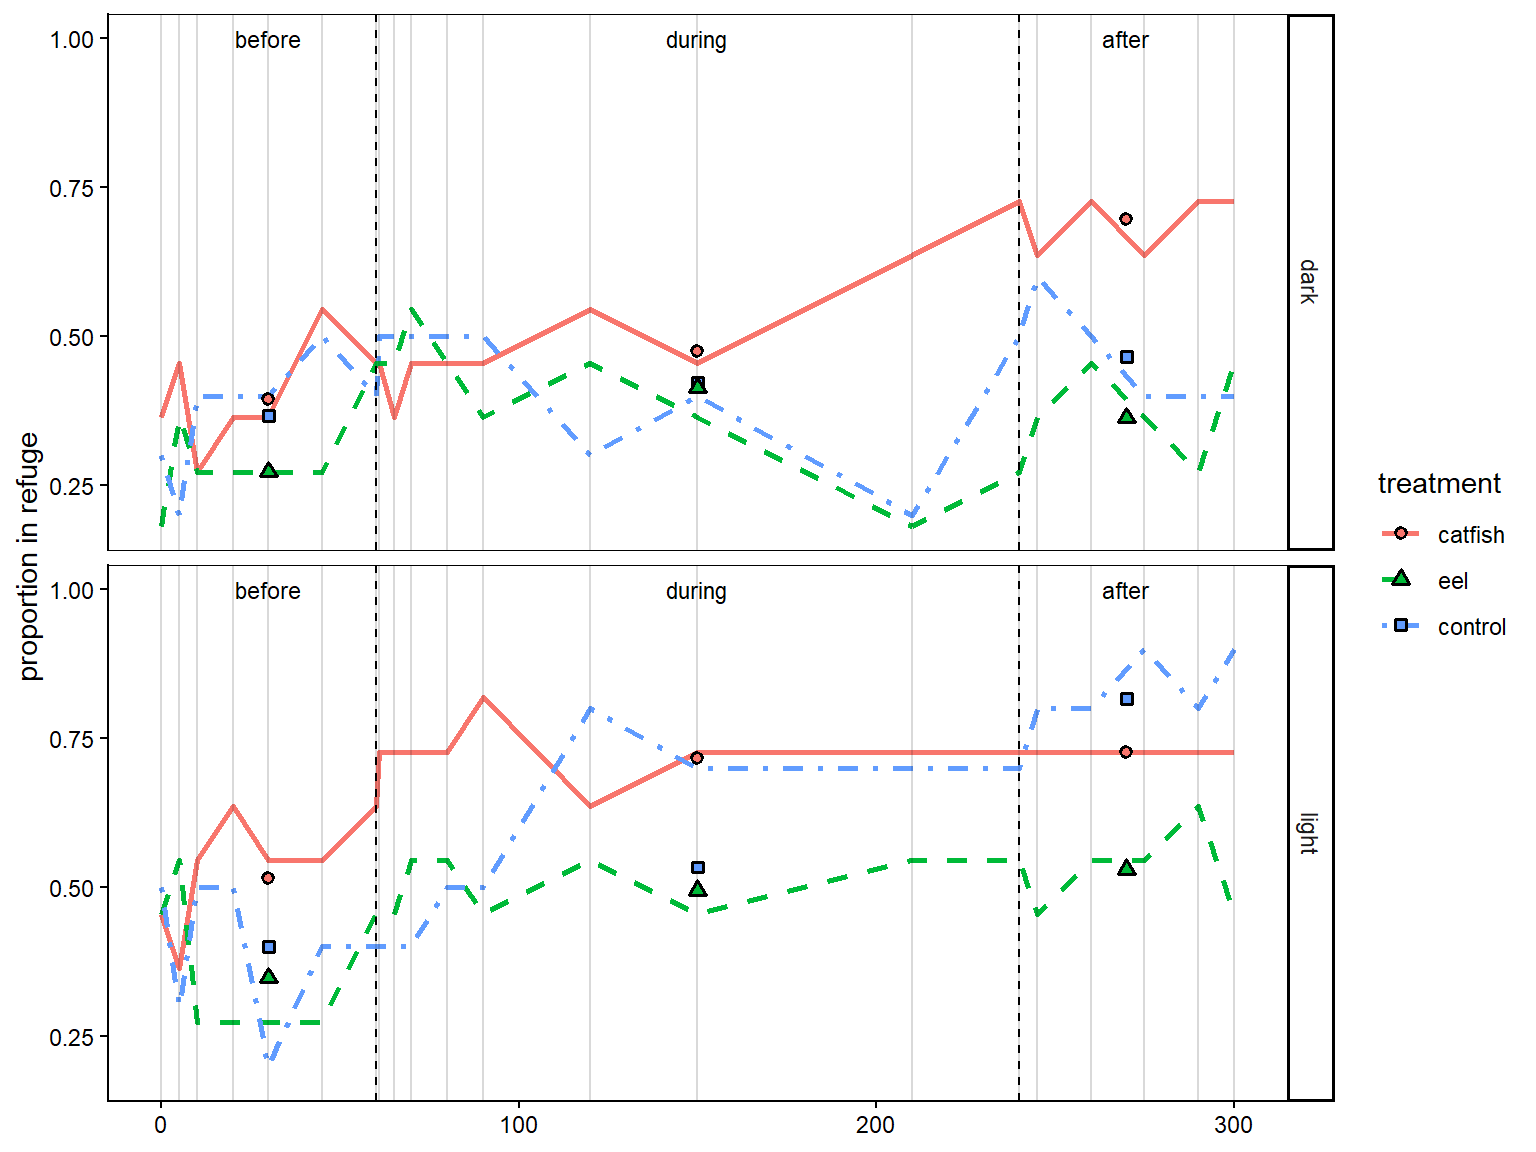

In [ ]:
#| label: fig-refuge-plot
#| include: true
#| fig-cap: "Kōura use of refuge over course of experiment with the three periods (before, during, after), the treatment (catfish; red-solid circle, eel; green-dashed triangle, control; blue-dotdash square), and divided over light regime (combined, dark, light). The points represent the proportion within each period for each treatment."

loc_order_ref <- c("refuge","open")

# calculate the proportions of location for each treatment for each time step
prop_location_time <- koura_long_ref %>%
  filter(!is.na(location), location != "") %>%
  count(treatment, time, light, location = location, name = "n") %>%
  group_by(treatment, time, light) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = loc_order_ref))

# Create combined light data
prop_location_time_combined <- prop_location_time %>%
  group_by(treatment, time, location) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(treatment, time) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(light = "combined")

period_x <- c("before" = 30, "during" = 150, "after" = 270)

prop_overlay <- prop_refuge_light_treat %>%
  mutate(time = period_x[period], treatment = factor(treatment, levels = c("catfish", "eel", "control")))

prop_overlay_combined <- prop_refuge_treat %>%
  mutate(time = period_x[period], 
         treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# Bind combined with separated
plot_data <- bind_rows(prop_location_time, prop_location_time_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

overlay_data <- bind_rows(prop_overlay, prop_overlay_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

refuge_plot <- prop_location_time %>%
  dplyr::filter(location == "refuge") %>%
  ggplot2::ggplot(aes(time, prop, colour = treatment, group = treatment, linetype = treatment)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  geom_vline(xintercept = c(0, 5, 10, 20, 30, 45, 60, 61, 65, 70, 80, 90, 120, 150, 210, 240, 245, 260, 275, 290, 300), alpha = .15) +
  geom_point(data = prop_overlay,  aes(x = time, y = prop_refuge, fill = treatment, shape = treatment), stroke = 1, col = "black") +
  annotate("text", x = 30,  y = 1, label = "before", size = 3) +
  annotate("text", x = 150, y = 1, label = "during", size = 3) +
  annotate("text", x = 270, y = 1, label = "after",  size = 3) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  scale_shape_manual(values = c(21, 24, 22)) +
  facet_grid(light ~ ., scales = "free_x") +
  labs(x = NULL, y = "proportion in refuge", 
       colour = "treatment", linetype = "treatment", shape = "treatment")

ggsave(file.path(out_dir, "refuge_plot.png"), refuge_plot, width = 8, height = 5, dpi = 300)

## Refuge stats

                          model      AIC      BIC    logLik delta_AIC
m7_no_re               m7_no_re 688.3155 711.1179 -337.1577      0.00
m1_main                 m1_main 689.1152 715.1752 -336.5576      0.80
m8_tank_round     m8_tank_round 690.1033 719.4207 -336.0516      1.79
m4_light_period m4_light_period 691.7566 724.3316 -335.8783      3.44
m3_trt_light       m3_trt_light 692.8617 725.4367 -336.4309      4.55
m2_trt_period     m2_trt_period 694.7197 733.8096 -335.3598      6.40
m5_twoway             m5_twoway 701.1463 753.2663 -334.5732     12.83
m9_null                 m9_null 703.3633 713.1358 -348.6816     15.05
m6_full                 m6_full 707.9106 773.0605 -333.9553     19.60

 Family: betabinomial  ( logit )
Formula:          
cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period
Data: round_summary

      AIC       BIC    logLik -2*log(L)  df.resid 
    688.3     711.1    -337.2     674.3       185 


Dispersion parameter for betabinomial family (): 0.631 

Conditional model:
                 Estimate Std. Error z value Pr(>|z|)   
(Intercept)       -0.0581     0.2821  -0.206  0.83682   
treatmentcatfish   0.4237     0.2917   1.452  0.14642   
treatmenteel      -0.4270     0.2941  -1.452  0.14656   
lightdark         -0.6542     0.2390  -2.737  0.00619 **
periodduring       0.5298     0.2816   1.881  0.05995 . 
periodafter        0.9125     0.3001   3.040  0.00236 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

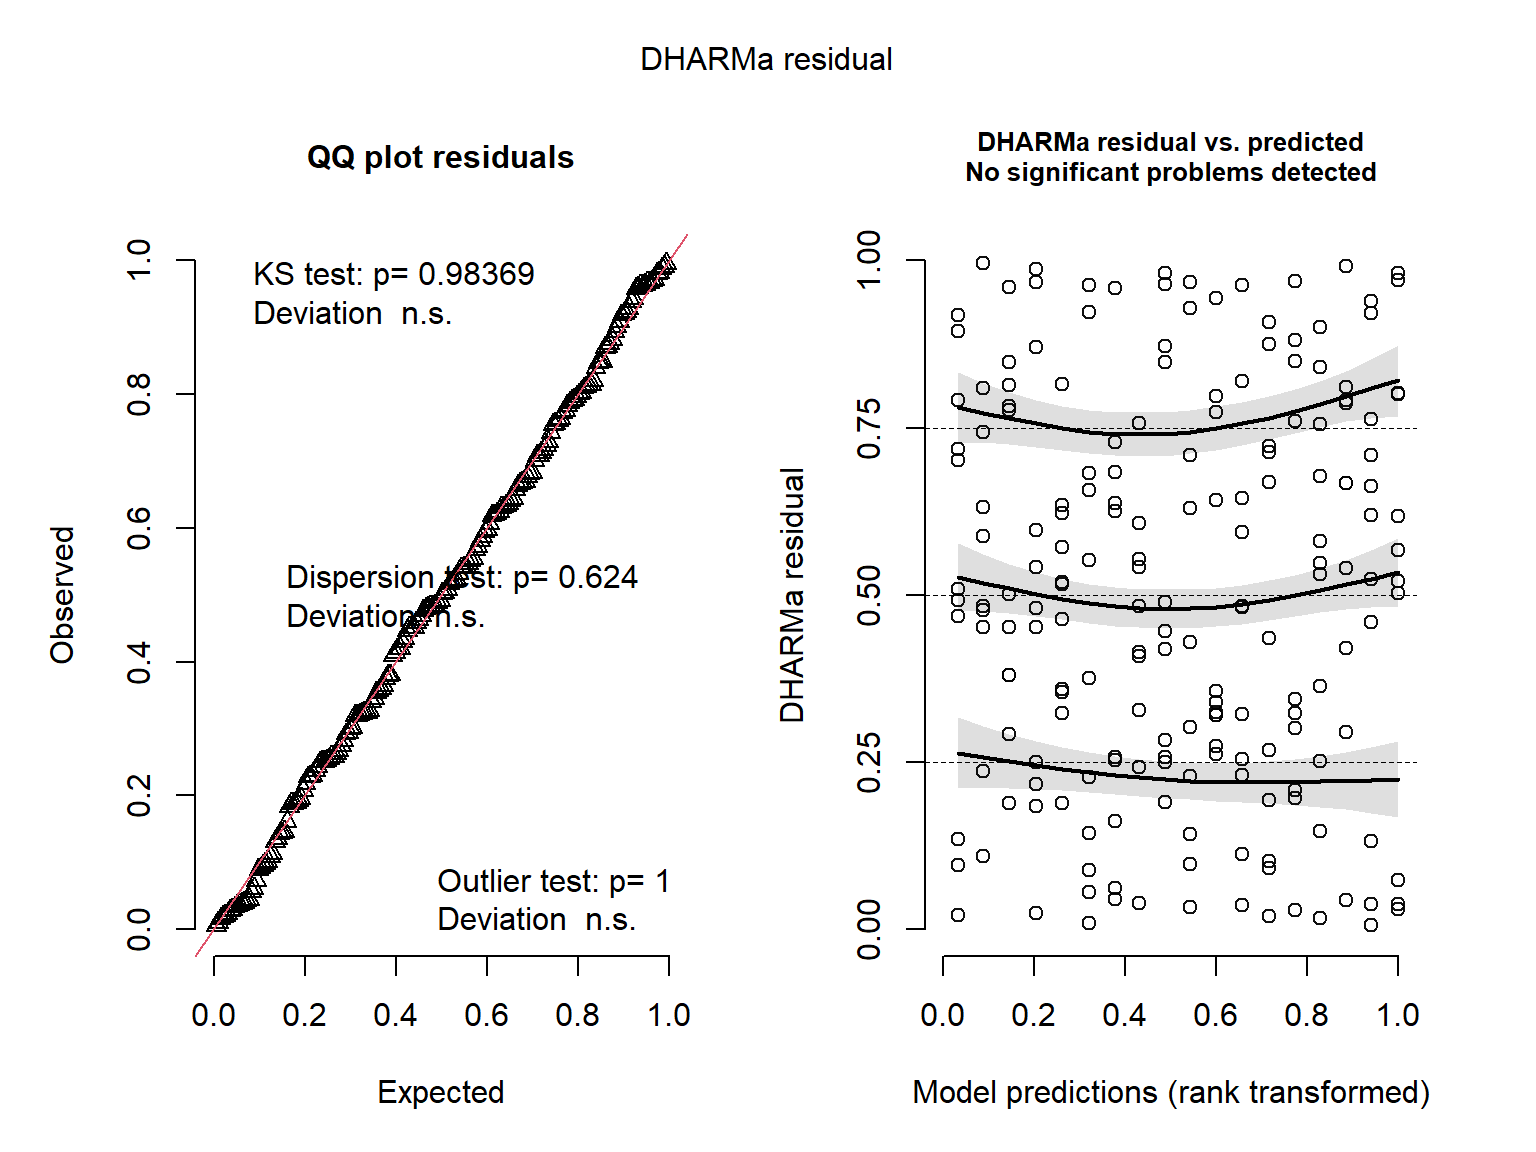

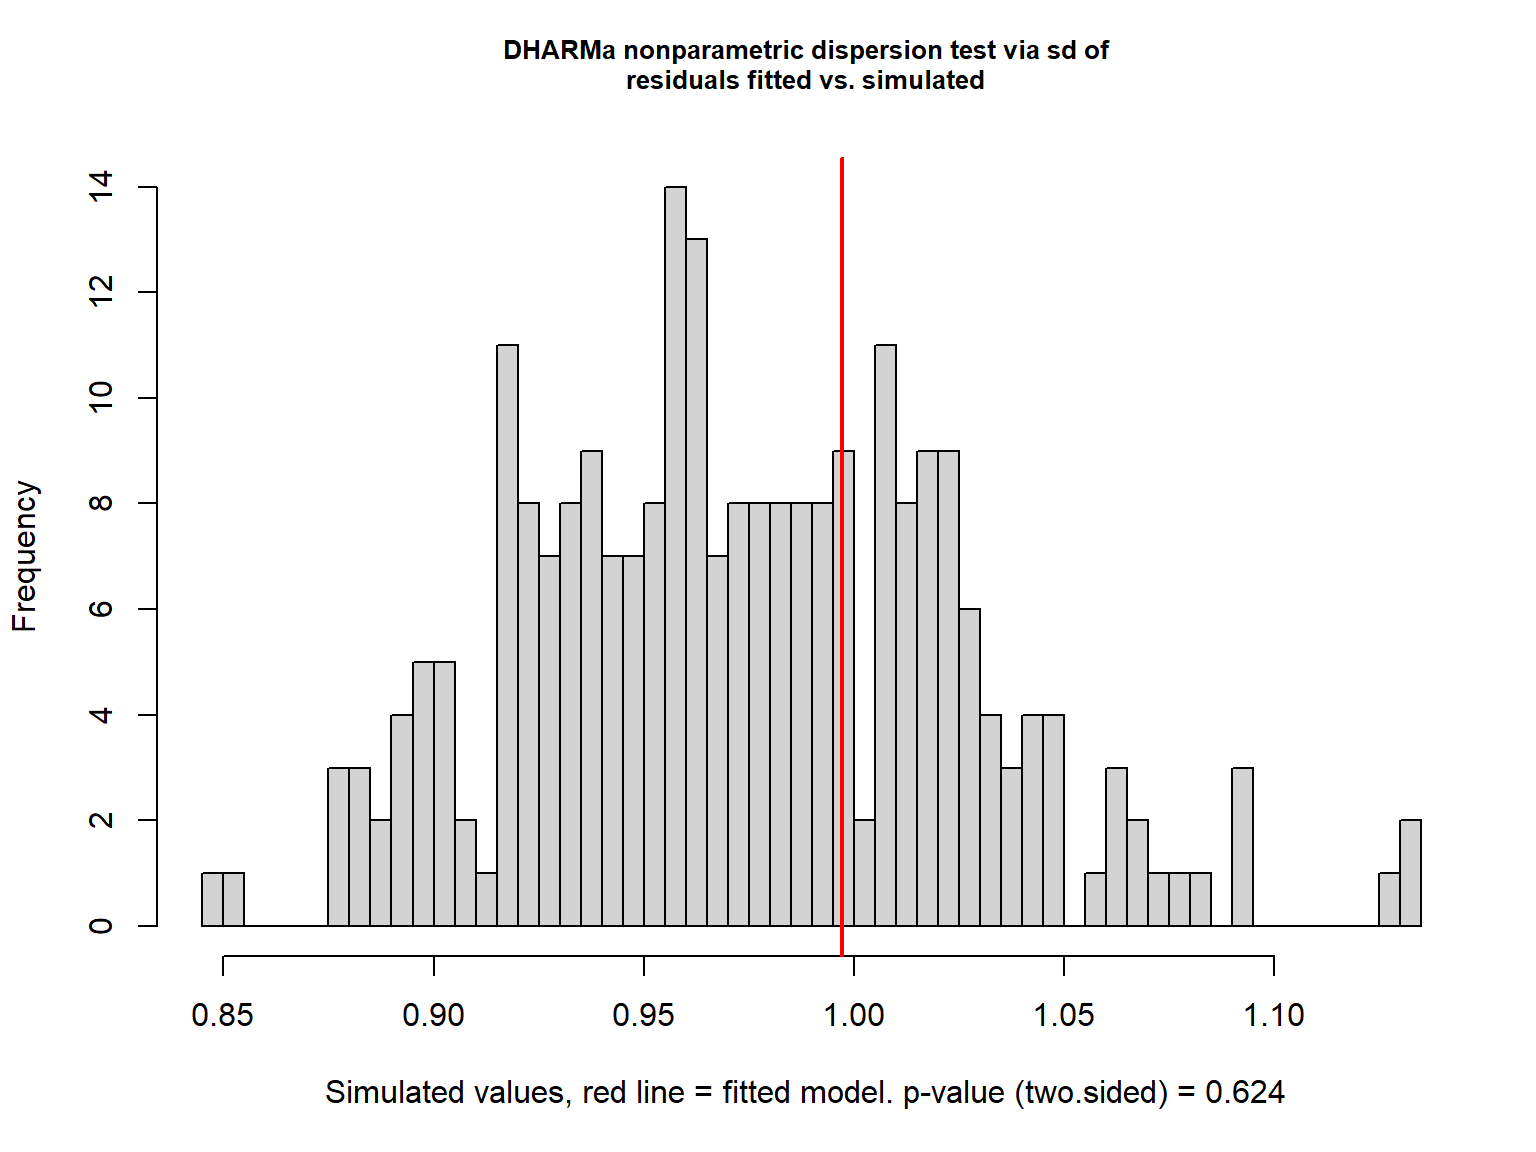


    DHARMa nonparametric dispersion test via sd of residuals fitted vs.
    simulated

data:  simulationOutput
dispersion = 1.0247, p-value = 0.624
alternative hypothesis: two.sided

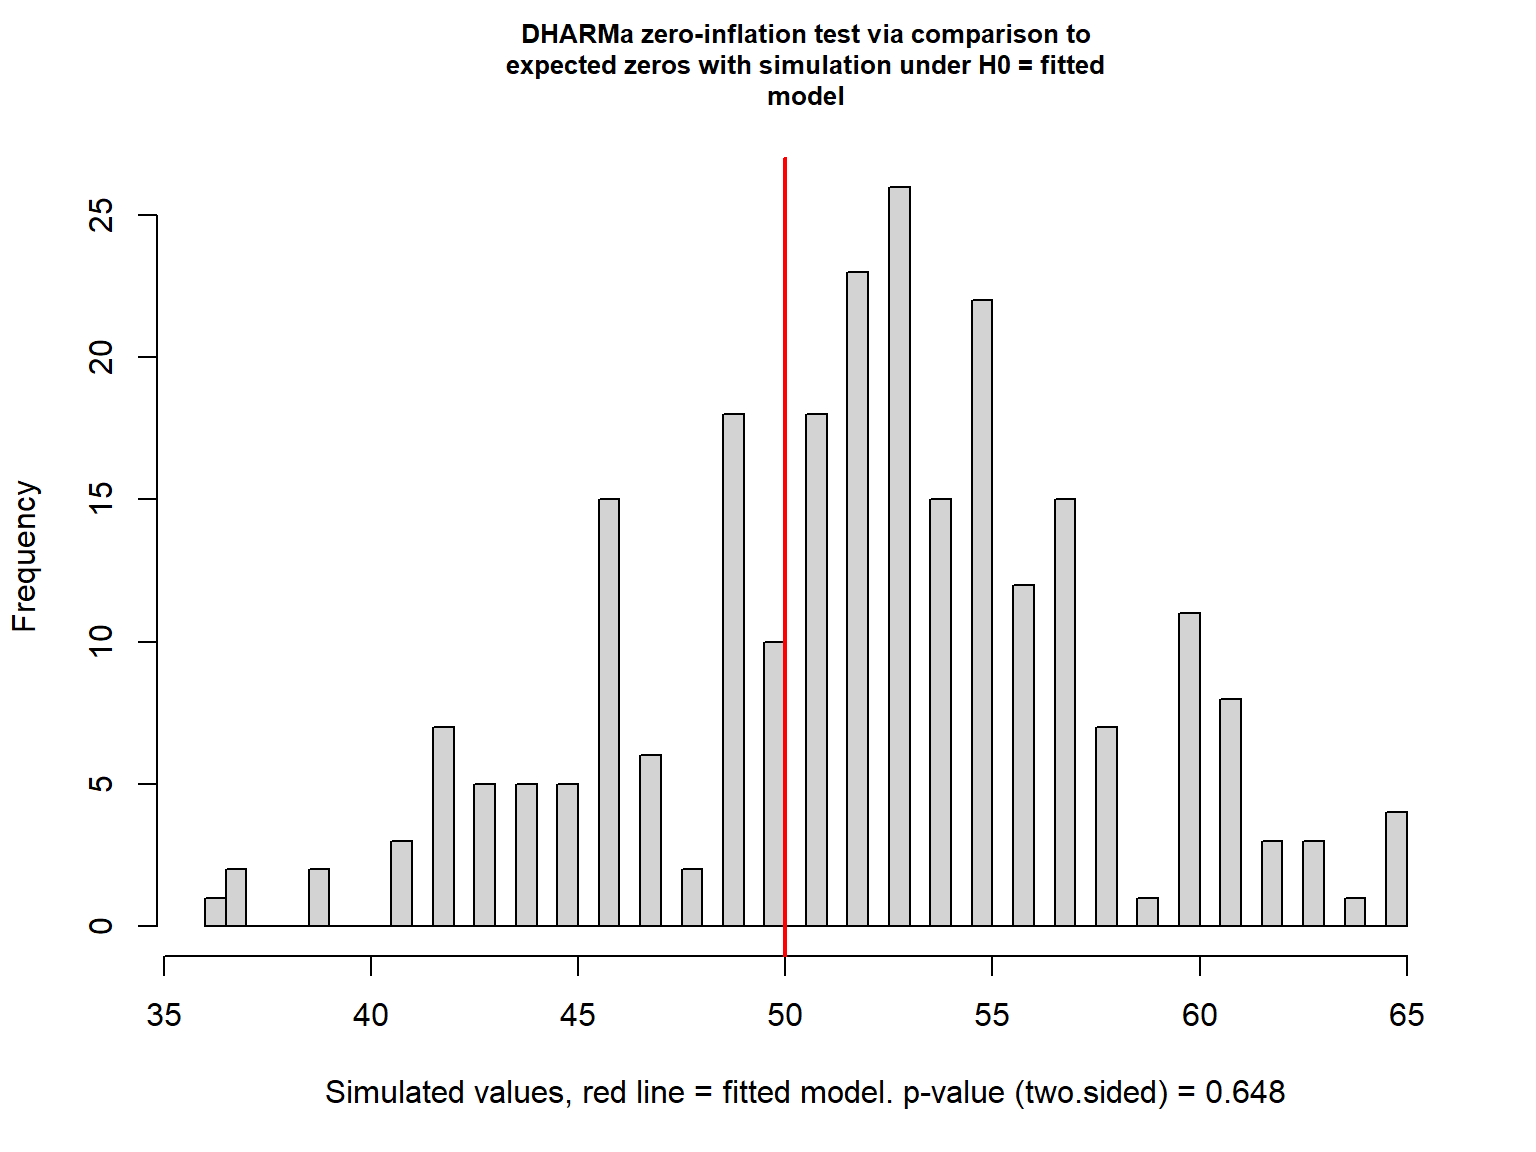


    DHARMa zero-inflation test via comparison to expected zeros with
    simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.95668, p-value = 0.648
alternative hypothesis: two.sided

In [ ]:
#| label: refuge-stats
#| include: false

koura_stat <- koura_long_ref %>%
  select(treatment, exp_id, round, tank, time, period, light, location, koura_id, size_mm1, weight_g1) %>%
  mutate(
    location = factor(location, levels = c("refuge", "open")),
    period   = factor(period,   levels = c("before", "during", "after")),
    tank     = factor(tank))

round_summary <- koura_stat %>%
  group_by(treatment, exp_id, round, tank, light, period, koura_id, size_mm1, weight_g1) %>%
  summarise(n_total  = n(),n_refuge = sum(location == "refuge"), .groups  = "drop") %>%
  mutate(treatment = relevel(factor(treatment), ref = "control"),
    light = relevel(factor(light), ref = "light"),   
    before = relevel(factor(period), ref = "before"))

# Model selection
models_bb <- list(
  # --- Fixed effects structure (with tank as random, the defensible RE) ---
  m1_main = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m2_trt_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * period + light + (1 | tank),
    data = round_summary, family = betabinomial),
  m3_trt_light = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m4_light_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m5_twoway = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + treatment * period + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m6_full = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  # --- Random effects structure (main effects fixed, vary RE) ---
  m7_no_re = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period,
    data = round_summary, family = betabinomial),
  m8_tank_round = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank) + (1 | round),
    data = round_summary, family = betabinomial),
  # --- Null model for baseline comparison ---
  m9_null = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ 1 + (1 | tank),
    data = round_summary, family = betabinomial)
)


comparison_bb <- data.frame(
  model  = names(models_bb),
  AIC    = sapply(models_bb, AIC),
  BIC    = sapply(models_bb, BIC),
  logLik = sapply(models_bb, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

print(comparison_bb)

### fixed effect tbl

In [ ]:
#| label: tbl-s2-fixed-effects
#| include: true
#| tbl-cap: "Fixed effects of the beta-binomial GLMM for kōura refuge use."

# Save fixed effects table 
fixed_bb <- as.data.frame(summary(m_final)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(fixed_bb, file.path(out_dir, "table_bb_fixed_effects.csv"), row.names = FALSE)

knitr::kable(fixed_bb, col.names = c("Term", "Estimate", "Std. Error", "z value", "p value"))

  Term                 Estimate   Std. Error   z value   p value
  ------------------ ---------- ------------ --------- ---------
  (Intercept)            -0.058        0.282    -0.206     0.837
  treatmentcatfish        0.424        0.292     1.452     0.146
  treatmenteel           -0.427        0.294    -1.452     0.147
  lightdark              -0.654        0.239    -2.737     0.006
  periodduring            0.530        0.282     1.881     0.060
  periodafter             0.912        0.300     3.040     0.002


### Emmeans tbl

In [ ]:
#| label: tbl-s3-emmeans
#| include: true
#| tbl-cap: "Pairwise contrasts from the beta-binomial GLMM for kōura refuge use. Odds ratios and p-values are shown for treatment, light condition, and period comparisons. P-values are Tukey-adjusted for multiple comparisons within each factor."

# Marginal means and pairwise contrasts 
emm_treatment <- as.data.frame(pairs(emmeans(m_final, ~ treatment, type = "response"))) %>% mutate(factor = "treatment")
emm_light     <- as.data.frame(pairs(emmeans(m_final, ~ light,     type = "response"))) %>% mutate(factor = "light")
emm_period    <- as.data.frame(pairs(emmeans(m_final, ~ period,    type = "response"))) %>% mutate(factor = "period")

emmeans_bb <- bind_rows(emm_treatment, emm_light, emm_period) %>%
  mutate(across(where(is.numeric), round, 3))


# Get emmeans for each factor
emm_treatment <- emmeans(m_final, ~ treatment, type = "response")
emm_light     <- emmeans(m_final, ~ light, type = "response")
emm_period    <- emmeans(m_final, ~ period, type = "response")

# Compute CLDs for each factor
cld_treatment <- multcomp::cld(emm_treatment, Letters = letters, adjust = "tukey")

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons

Note: adjust = "tukey" was changed to "sidak"
because "tukey" is only appropriate for one set of pairwise comparisons

  ---------------------------------------------------------------------------------
  Contrast            Odds ratio      SE    df   Null  z value  p value Factor
  ------------------ ----------- ------- ----- ------ -------- -------- -----------
  control / catfish        0.655   0.191   Inf      1   -1.452    0.314 treatment

  control / eel            1.533   0.451   Inf      1    1.452    0.314 treatment

  catfish / eel            2.341   0.681   Inf      1    2.924    0.010 treatment

  light / dark             1.924   0.460   Inf      1    2.737    0.006 light

  before / during          0.589   0.166   Inf      1   -1.881    0.144 period

  before / after           0.402   0.121   Inf      1   -3.040    0.007 period

  during / after           0.682   0.205   Inf      1   -1.276    0.409 period
  ---------------------------------------------------------------------------------


## Emmeans plot

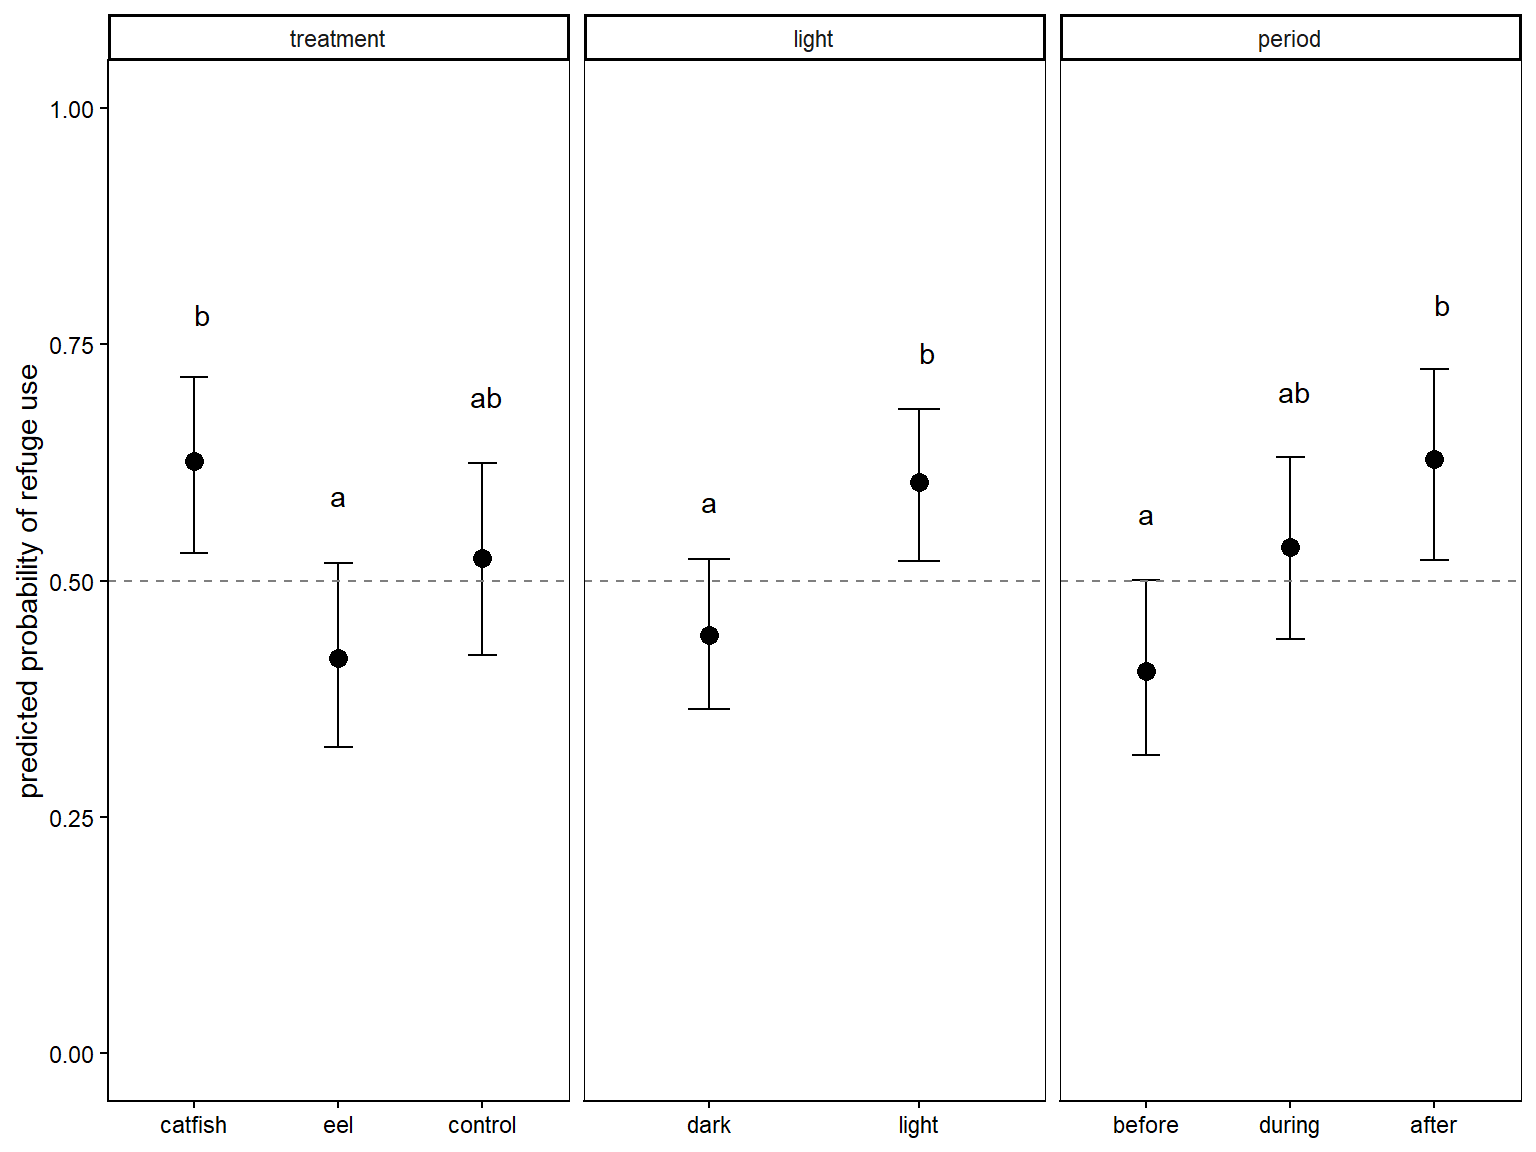

In [ ]:
#| label: fig-emmeans-plot
#| include: true
#| fig-cap: "Predicted marginal probabilities of refuge use from the beta-binomial GLMM for each level of treatment, light condition, and experimental period. Points represent model-estimated marginal means averaged over other factors, with 95% confidence intervals shown as error bars. Different letters (a, b) indicate statistically significant differences between groups within each factor based on Tukey-adjusted pairwise comparisons. The dashed line at 0.5 marks the threshold where kōura spend half their time in refuge."

# Make plot
# get predicted probabilities (not contrasts) for plotting
emm_treat_pred  <- as.data.frame(emmeans(m_final, ~ treatment, type = "response"))
emm_light_pred  <- as.data.frame(emmeans(m_final, ~ light,     type = "response"))
emm_period_pred <- as.data.frame(emmeans(m_final, ~ period,    type = "response"))


# add factor label and rename x variable
emm_treat_pred  <- emm_treat_pred  %>% mutate(factor = "treatment", x = treatment)
emm_light_pred  <- emm_light_pred  %>% mutate(factor = "light",     x = light)
emm_period_pred <- emm_period_pred %>% mutate(factor = "period",    x = period)


emm_all <- bind_rows(emm_treat_pred, emm_light_pred, emm_period_pred) %>%
  mutate(factor = factor(factor, levels = c("treatment", "light", "period")),
         x = factor(x, levels = c("catfish", "eel", "control", "dark", "light", "before", "during", "after")))

emmeans_plot <- ggplot(emm_all, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  geom_text(data = cld_all, aes(x = x, y = asymp.UCL + 0.05, label = .group), inherit.aes = FALSE) +
  facet_wrap(~ factor, scales = "free_x") +
  scale_y_continuous("predicted probability of refuge use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50")

ggsave(file.path(out_dir, "emmeans_plot.png"), emmeans_plot, width = 5, height = 3, dpi = 300)

emmeans_plot

## Summary table of koura used

In [ ]:
#| label: tbl-koura
#| include: true
#| tbl-cap: "Summary of kōura used in experiments"

grps <- list(c("treatment","light"), "treatment", "light", character(0))
tags <- c("treatment+light","treatment","light","overall")

summary_animals <- Map(function(g, tag)
  df_NCE_raw %>%
    group_by(across(all_of(g))) %>%
    summarise(n_trials = n(), mean_size = mean(size_mm1, na.rm=TRUE), sd_size = sd(size_mm1, na.rm=TRUE), min_size  = min(size_mm1, na.rm = TRUE), max_size = max(size_mm1, na.rm = TRUE), mean_weight = mean(weight_g1, na.rm=TRUE), sd_weight = sd(weight_g1,       na.rm=TRUE),min_weight = min(weight_g1, na.rm = TRUE),
      max_weight = max(weight_g1, na.rm = TRUE),.groups="drop") %>%
    mutate(grouping=tag) %>%
    { if(!"treatment"%in%g) mutate(., treatment="All") else . } %>%
    { if(!"light"%in%g)     mutate(., light="All")     else . },
  grps, tags) %>%
  bind_rows() %>%
  select(grouping, treatment, light, everything()) %>%
  arrange(factor(grouping, levels=tags), treatment, light)

# need to make into nice table
knitr::kable(summary_animals, digits = 2)

  ------------------------------------------------------------------------------------------------------------------------------------------------
  grouping          treatment   light     n_trials   mean_size   sd_size   min_size   max_size   mean_weight   sd_weight   min_weight   max_weight
  ----------------- ----------- ------- ---------- ----------- --------- ---------- ---------- ------------- ----------- ------------ ------------
  treatment+light   catfish     dark            11       25.99      2.97      21.46      30.28         11.64        4.06            6           19

  treatment+light   catfish     light           11       26.45      1.53      23.84      28.47         11.45        2.91            8           17

  treatment+light   control     dark            10       25.93      4.76      18.35      32.95         11.60        6.79            3           23

  treatment+light   control     light           10       26.17      1.86      23.71      29.97         11.50        2.88            9           17

  treatment+light   eel         dark            11       25.16      4.37      18.35      30.95         12.00        5.62            3           21

  treatment+light   eel         light           11       26.66      2.12      23.58      29.49         12.00        2.86            8           17

  treatment         catfish     All             22       26.22      2.32      21.46      30.28         11.55        3.45            6           19

  treatment         control     All             20       26.05      3.52      18.35      32.95         11.55        5.07            3           23

  treatment         eel         All             22       25.91      3.44      18.35      30.95         12.00        4.35            3           21

  light             All         dark            32       25.68      3.97      18.35      32.95         11.75        5.38            3           23

  light             All         light           32       26.44      1.81      23.58      29.97         11.66        2.80            8           17

  overall           All         All             64       26.06      3.08      18.35      32.95         11.70        4.25            3           23
  ------------------------------------------------------------------------------------------------------------------------------------------------


## Plots individual koura

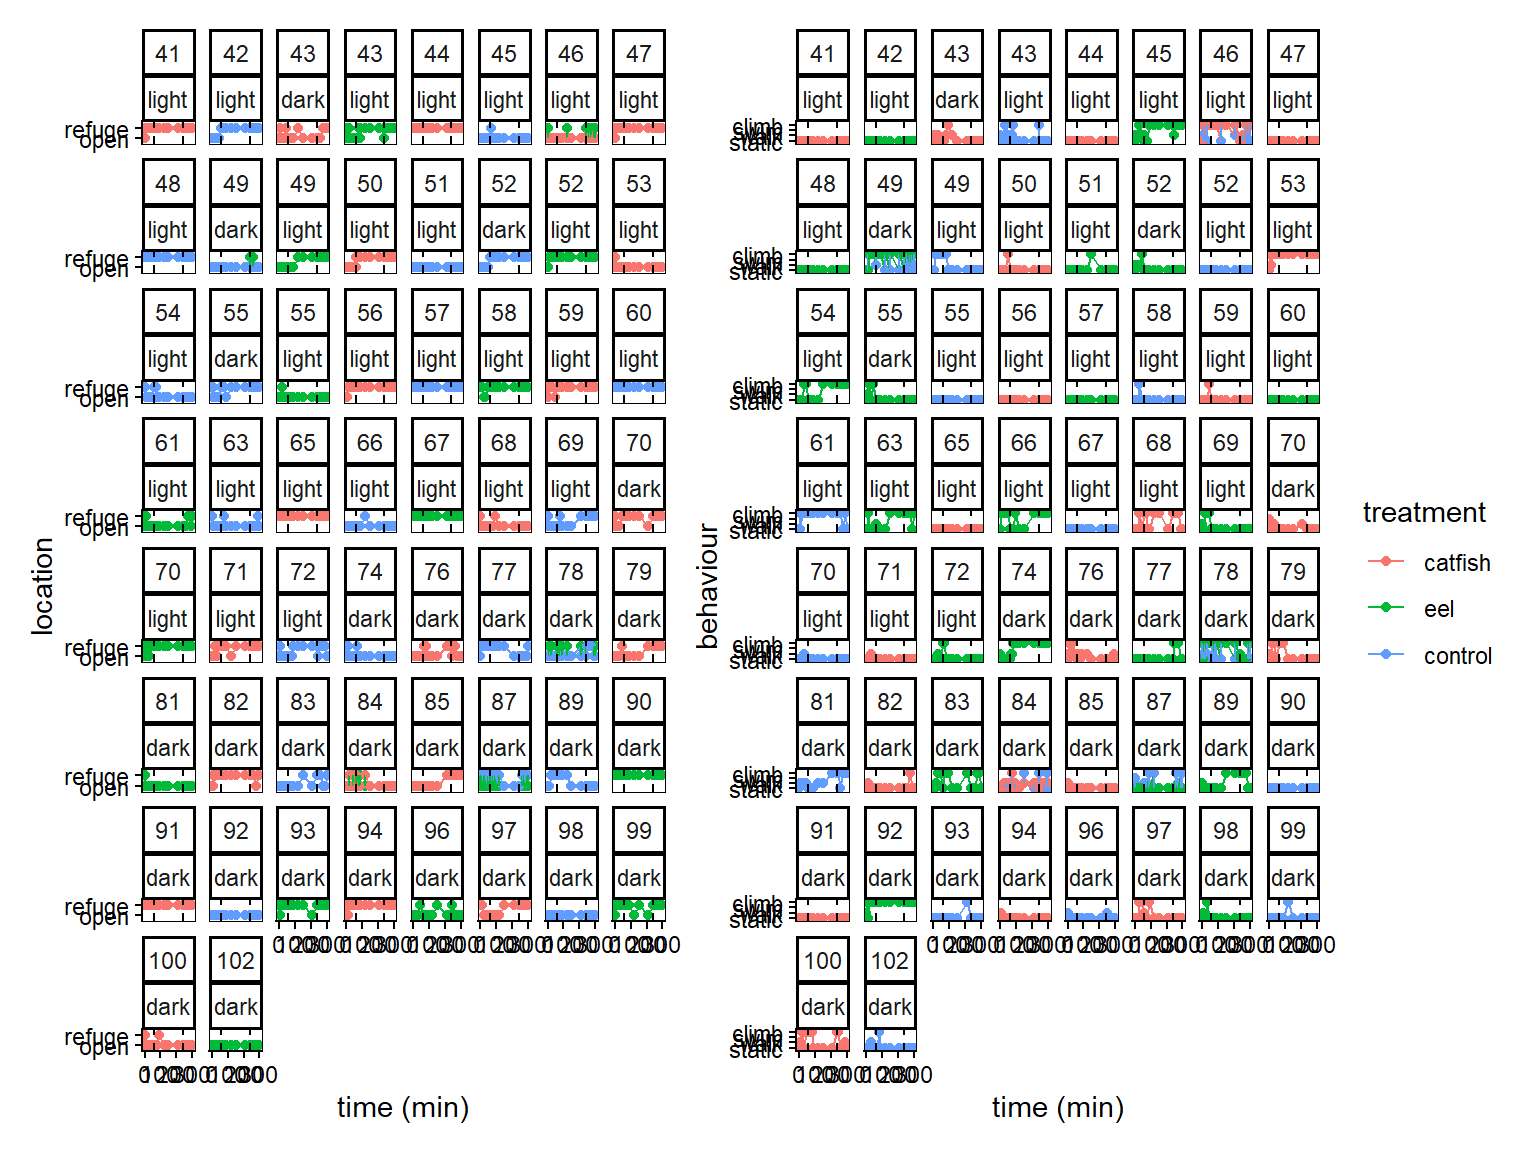

In [ ]:
#| label: fig-koura
#| include: true
#| fig-cap: "your caption"

loc_order <- c("ref_back","ref_open","ref_next","wall","floor","barrier")
beh_order <- c("static","walk","swim","climb")

koura_location_time <- koura_long %>%
  mutate(location = factor(location, levels = loc_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))


koura_behaviour_time <- koura_long %>%
  mutate(behaviour = factor(behaviour, levels = beh_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# --- Plots ---
p_loc_time <- ggplot(koura_long_ref, aes(time, location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = koura_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "time (min)", y = "location")+
  theme(legend.position = "none")

p_beh_time <- ggplot(koura_behaviour_time, aes(time, behaviour, col = treatment)) +
  geom_point() +
  geom_line(aes(group = koura_id))+
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "time (min)", y = "behaviour") 

# --- Combine ---
koura_time_plot <- p_loc_time + p_beh_time
koura_time_plot

## Repeated measurements

In [ ]:
#| label: repeated-measurements
#| include: true
#| fig-cap: "your caption"

repeated_ids <- unique(df_NCE_raw$koura_id[duplicated(df_NCE_raw$koura_id)])

df_repeated <- koura_long_ref %>% 
  filter(koura_id %in% repeated_ids) %>%
  filter(!is.na(location), location != "") %>%
  count(koura_id, treatment, exp_id, location = location, name = "n") %>%
  group_by(koura_id, exp_id) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = loc_order_ref))

# Collapse to one score per individual per trial - e.g. prop time refuge
refuge_score <- df_repeated %>%
  filter(location == "refuge") %>%
  group_by(koura_id, exp_id, treatment) %>%
  summarise(prop_refuge = mean(prop), .groups = "drop")

plot_repeated_time <- 
  koura_long_ref %>%
  filter(koura_id %in% repeated_ids) %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")))%>%
  ggplot(aes(x = time, y = location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = exp_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_grid(koura_id  ~ date) +
  labs(x = "time (min)", y = "location")

plot_repeated_time

## Koura size

In [ ]:
#| label: koura-size
#| include: true
#| fig-cap: "your caption"

m_size <- glmmTMB(
  cbind(n_refuge, n_total - n_refuge) ~ size_mm1 +  (1 | exp_id),
  data = round_summary, family = betabinomial)

summary(m_size)

 Family: betabinomial  ( logit )
Formula:          cbind(n_refuge, n_total - n_refuge) ~ size_mm1 + (1 | exp_id)
Data: round_summary

      AIC       BIC    logLik -2*log(L)  df.resid 
    656.7     669.7    -324.3     648.7       188 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 exp_id (Intercept) 3.25     1.803   
Number of obs: 192, groups:  exp_id, 64

Dispersion parameter for betabinomial family (): 1.49 

Conditional model:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -1.2050     2.2300  -0.540    0.589
size_mm1      0.0496     0.0850   0.584    0.560

## Barrier

In [ ]:
#| label: fig-barrier
#| include: true
#| fig-cap: "your caption"

koura_long_bar <- koura_long %>%
  mutate(location = case_when(
      location == "barrier" ~ "barrier",
      location %in% c("floor", "wall") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_ ),
    behaviour = case_when(
      behaviour == "climb" ~ "climbing",
      behaviour %in% c("static", "walk", "swim") ~ "other",
      TRUE ~ NA_character_))

# summarise barrier climbing per round
barrier_summary <- koura_long_bar %>%
  filter(!is.na(location)) %>%
  group_by(treatment, exp_id, round, tank, light, period) %>%
  summarise(
    n_total   = n(),
    n_barrier = sum(location == "barrier", na.rm = TRUE),
    .groups   = "drop"
  )

# check counts
barrier_summary_tbl <- barrier_summary %>%
  group_by(treatment, period) %>%
  summarise(mean_prop = mean(n_barrier/n_total), .groups = "drop")

knitr::kable(barrier_summary_tbl, digits = 2)

# Feeding experiment

## Feeding plot

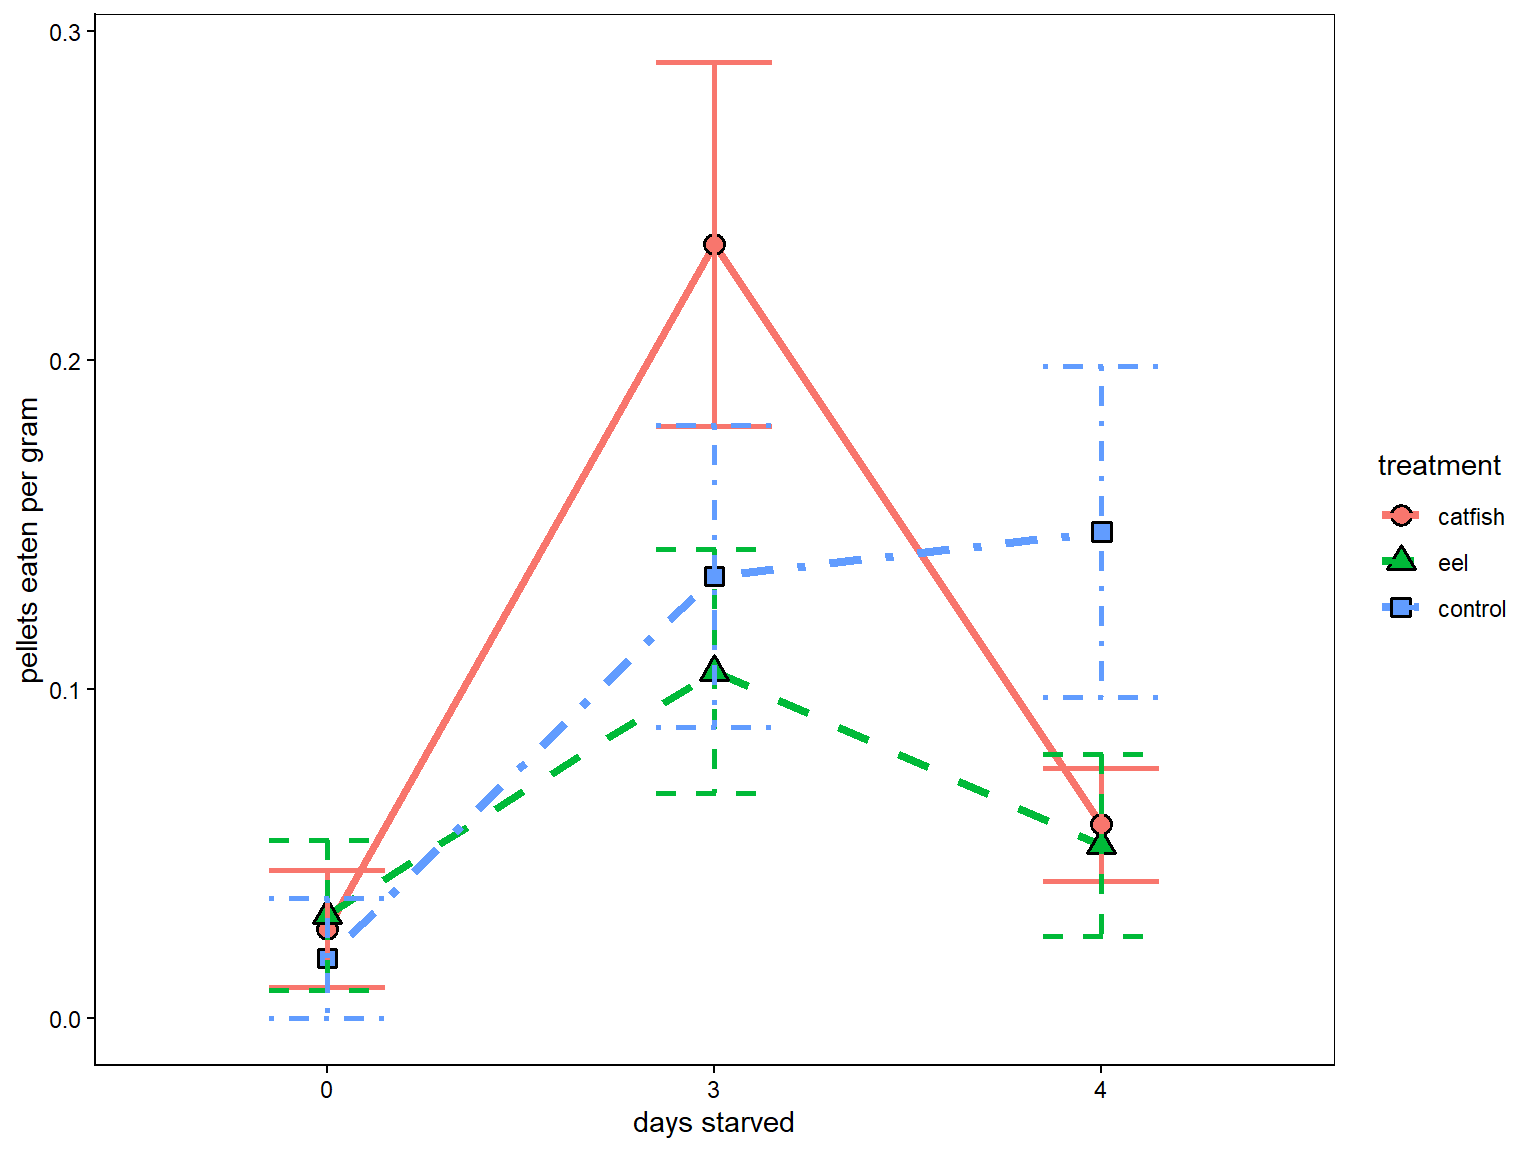

In [ ]:
#| label: fig-feeding-plot
#| include: true
#| fig-cap: "Mean kōura feeding rate (pellets consumed per gram body weight ± SE) across predator treatments (catfish, eel, control) and starvation periods (0, 3, and 4 days). Points represent treatment means and error bars show standard error."

df_feeding <- df_Feeding_raw %>%
  mutate(pellets_eaten_24h = total_fed - left_after_24h,
    pellets_per_g = pellets_eaten_24h / weight_g,
    koura_id = as.factor(koura_id),
    treatment = as.factor(treatment),
    day_starve = as.factor(day_starve),
    treatment = factor(treatment, levels = c("catfish", "eel", "control")))

feeding_plot <- ggplot(df_feeding, aes(day_starve, pellets_per_g, col = treatment, group = treatment, linetype = treatment)) +
  stat_summary(fun = mean, geom = "line", linewidth = 1.5) +
  stat_summary(fun = mean, geom = "point",aes(fill = treatment, shape = treatment), stroke = 1, col = "black", size = 3) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.3, linewidth = 1) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  scale_shape_manual(values = c(21, 24, 22)) +
  labs(x = "days starved", y = "pellets eaten per gram", col = "treatment", linetype = "treatment", shape = "treatment", fill = "treatment")

ggsave(file.path(out_dir, "feeding_plot.png"), feeding_plot, width = 8, height = 5, dpi = 300)

feeding_plot

## Feeding stats

   model       AIC       BIC   logLik delta_AIC
m1    m1 -92.78035 -74.06834 56.39018      0.00
m3    m3 -92.78035 -74.06834 56.39018      0.00
m6    m6 -92.04488 -84.56008 50.02244      0.74
m2    m2 -90.84779 -79.62058 51.42389      1.93
m4    m4 -90.84779 -79.62058 51.42389      1.93
m5    m5 -77.96702 -70.48221 42.98351     14.81

Anova Table (Type III tests)

Response: pellets_per_g
                       Sum Sq Df F value    Pr(>F)    
(Intercept)          0.004401  1  0.6401 0.4285109    
treatment            0.000446  2  0.0325 0.9680855    
day_starve           0.131605  2  9.5709 0.0004152 ***
treatment:day_starve 0.061643  4  2.2415 0.0821411 .  
Residuals            0.268134 39                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 treatment day_starve emmean     SE df lower.CL upper.CL
 catfish   0          0.0271 0.0339 39  -0.0414   0.0956
 eel       0          0.0312 0.0371 39  -0.0438   0.1062
 control   0          0.0182 0.0371 39  -0.0568   0.0932
 catfish   3          0.2351 0.0371 39   0.1601   0.3101
 eel       3          0.1052 0.0339 39   0.0367   0.1737
 control   3          0.1342 0.0371 39   0.0592   0.2092
 catfish   4          0.0587 0.0371 39  -0.0163   0.1337
 eel       4          0.0524 0.0371 39  -0.0226   0.1274
 control   4          0.1477 0.0339 39   0.0792   0.2162

Confidence level used: 0.95 


    Shapiro-Wilk normality test

data:  residuals(lm_feed)
W = 0.97279, p-value = 0.324

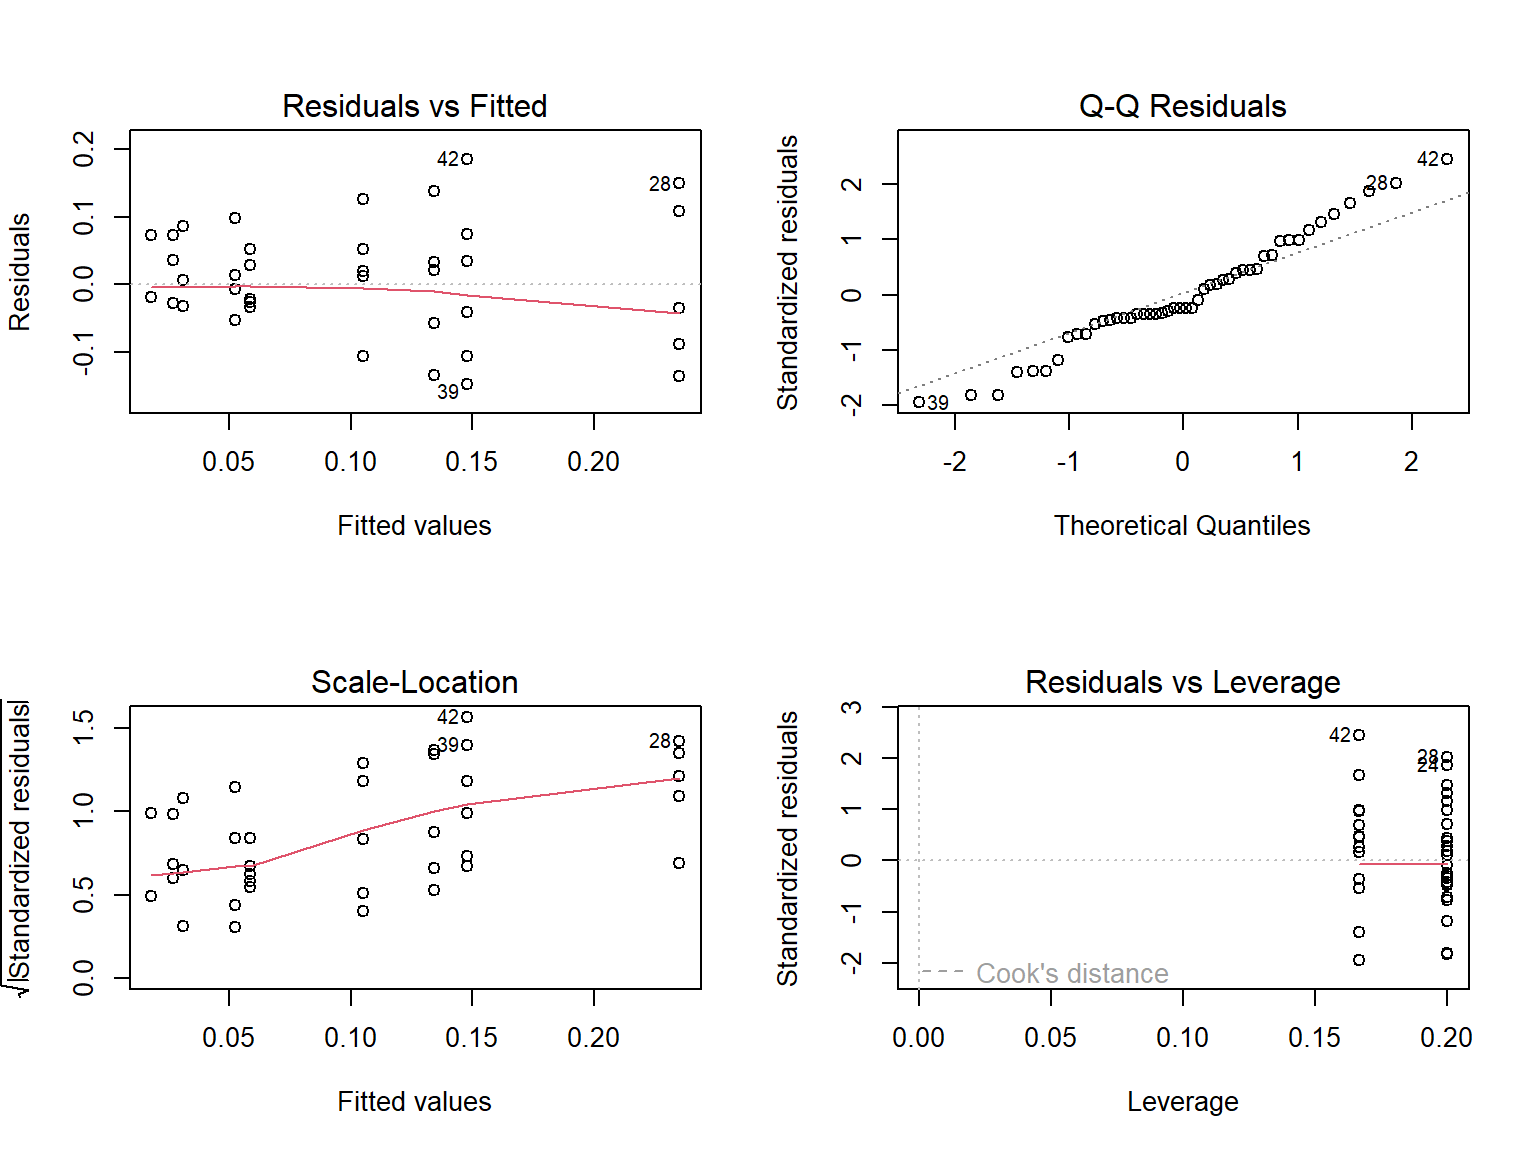

In [ ]:
#| label: feeding-stats
#| include: false

# Model selection

feeding_models <- list(
  m1 = lm(pellets_per_g ~ treatment * day_starve, data = df_feeding),
  m2 = lm(pellets_per_g ~ treatment + day_starve, data = df_feeding),
  m3 = lm(pellets_per_g ~ treatment * day_starve + (1 | exp_tank ), data = df_feeding),
  m4 = lm(pellets_per_g ~ treatment + day_starve + (1 | exp_tank ), data = df_feeding),
  m5 = lm(pellets_per_g ~ treatment, data = df_feeding),
  m6 = lm(pellets_per_g ~ day_starve, data = df_feeding))

comparison_feeding_models <- data.frame(
  model  = names(feeding_models),
  AIC    = sapply(feeding_models, AIC),
  BIC    = sapply(feeding_models, BIC),
  logLik = sapply(feeding_models, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

print(comparison_feeding_models)

### feeding anova tbl

In [ ]:
#| label: tbl-s4-feeding-anova
#| include: true
#| tbl-cap: "Type III ANOVA table for the linear model of kōura feeding rate (pellets consumed per gram body weight). Treatment, starvation period, and their interaction were included as fixed effects."

as.data.frame(anova_feed) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3)) %>%
  knitr::kable(col.names = c("Term", "Sum Sq", "Df", "F value", "p value"))

  Term                     Sum Sq   Df   F value   p value
  ---------------------- -------- ---- --------- ---------
  (Intercept)               0.004    1     0.640     0.429
  treatment                 0.000    2     0.032     0.968
  day_starve                0.132    2     9.571     0.000
  treatment:day_starve      0.062    4     2.241     0.082
  Residuals                 0.268   39        NA        NA


```` markdown
---
title: "Analysis Notebook"
format:
  html:
    fig-path: "analysis_files/figure-html/"
    theme:
      light: flatly
      dark: darkly
    code-fold: true
    code-tools: true
    code-summary: "View Code"
    toc: true
    toc-depth: 3
    number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false

options(warn = -1)

packages <- c("multcomp","DT","car","glmmTMB","AICcmodavg", "ggeffects","DHARMa", "brms", "emmeans", "lme4","lmerTest","vegan","ggnewscale","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

# Load packages if not already installed
quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

exc_file_dir <- "data/raw/NCE_data.xlsx"
der_data_dir <- "data/derived"
out_dir      <- "outputs"

# Read sheets from raw xlsx
df_NCE_raw <- readxl::read_excel(exc_file_dir, sheet = "NCE_exp")
df_Feeding_raw <- readxl::read_excel(exc_file_dir, sheet = "Feeding")

# Save as csv to derived/
write.csv(df_NCE_raw,     file.path(der_data_dir, "NCE_exp.csv"),  row.names = FALSE)
write.csv(df_Feeding_raw, file.path(der_data_dir, "Feeding.csv"),  row.names = FALSE)

df_NCE_raw     <- read.csv(file.path(der_data_dir, "NCE_exp.csv"))
df_Feeding_raw <- read.csv(file.path(der_data_dir, "Feeding.csv"))

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "sans", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

```

# Refuge experiment
## Build refuge dataframe
quarto-executable-code-5450563D

```r
#| label: build-df
#| include: false

df_NCE_raw <- df_NCE_raw %>%
  dplyr::select(-location_T180, -behaviour_T180)

# make into long format
koura_long <- df_NCE_raw %>%
  pivot_longer(
    cols = matches("^(location|behaviour)_"),
    names_to   = c(".value","time"),
    names_pattern = "(location|behaviour)_T?(\\d+)" ) %>%
  mutate(time = as.numeric(time))

koura_long <- koura_long %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

#Group all refuge used
koura_long_ref <- koura_long %>%
  mutate(
    location = case_when(
      location %in% c("floor", "wall", "barrier") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_))

koura_long_ref <- koura_long_ref %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

```

## Refuge table
quarto-executable-code-5450563D

```r
#| label: tbl-s1-refuge-prop
#| include: true
#| tbl-cap: "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge."

prop_refuge_light_treat <- koura_long_ref %>%
  dplyr::group_by(light, treatment, period) %>%
  dplyr::summarise(
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_treat <- koura_long_ref %>%
  dplyr::group_by(treatment, period) %>%
  dplyr::summarise(light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_light <- koura_long_ref %>%
  dplyr::group_by(light, period) %>%
  dplyr::summarise(treatment = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_per <- koura_long_ref %>%
  dplyr::group_by(period) %>%
  dplyr::summarise(treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_comb <- koura_long_ref %>%
  dplyr::summarise(period = "combined",
    treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

refuge_table <- dplyr::bind_rows(prop_refuge_light_treat, prop_refuge_treat,prop_refuge_light, prop_refuge_per, prop_refuge_comb) %>%
  mutate_if(is.numeric, round, digits = 2)

# extract specific values for inline reporting
get_prop <- function(l, t, p) {
  refuge_table %>% 
    filter(light == l, treatment == t, period == p) %>% 
    pull(prop_refuge)
}

write.csv(refuge_table, file = file.path(out_dir, "refuge_table.csv"), row.names = FALSE)

if (knitr::is_html_output()) {
  datatable(
    refuge_table,
    caption = "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge.",
    filter = "top",
    options = list(
      pageLength = 37,
      dom = 'Bfrtip',
      buttons = c('csv', 'excel'),
      columnDefs = list(list(className = 'dt-center', targets = "_all"))
    ),
    extensions = 'Buttons',
    rownames = FALSE,
    colnames = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
  ) |>
    formatRound(columns = "prop_refuge", digits = 2) |>
    formatStyle(
      "prop_refuge",
      background = styleColorBar(range(refuge_table$prop_refuge), "lightblue"),
      backgroundSize = "100% 90%",
      backgroundRepeat = "no-repeat",
      backgroundPosition = "center"
    )
} else {
  knitr::kable(refuge_table, digits = 2)
}

```

## Refuge plot
quarto-executable-code-5450563D

```r
#| label: fig-refuge-plot
#| include: true
#| fig-cap: "Kōura use of refuge over course of experiment with the three periods (before, during, after), the treatment (catfish; red-solid circle, eel; green-dashed triangle, control; blue-dotdash square), and divided over light regime (combined, dark, light). The points represent the proportion within each period for each treatment."

loc_order_ref <- c("refuge","open")

# calculate the proportions of location for each treatment for each time step
prop_location_time <- koura_long_ref %>%
  filter(!is.na(location), location != "") %>%
  count(treatment, time, light, location = location, name = "n") %>%
  group_by(treatment, time, light) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = loc_order_ref))

# Create combined light data
prop_location_time_combined <- prop_location_time %>%
  group_by(treatment, time, location) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(treatment, time) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(light = "combined")

period_x <- c("before" = 30, "during" = 150, "after" = 270)

prop_overlay <- prop_refuge_light_treat %>%
  mutate(time = period_x[period], treatment = factor(treatment, levels = c("catfish", "eel", "control")))

prop_overlay_combined <- prop_refuge_treat %>%
  mutate(time = period_x[period], 
         treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# Bind combined with separated
plot_data <- bind_rows(prop_location_time, prop_location_time_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

overlay_data <- bind_rows(prop_overlay, prop_overlay_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

refuge_plot <- prop_location_time %>%
  dplyr::filter(location == "refuge") %>%
  ggplot2::ggplot(aes(time, prop, colour = treatment, group = treatment, linetype = treatment)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  geom_vline(xintercept = c(0, 5, 10, 20, 30, 45, 60, 61, 65, 70, 80, 90, 120, 150, 210, 240, 245, 260, 275, 290, 300), alpha = .15) +
  geom_point(data = prop_overlay,  aes(x = time, y = prop_refuge, fill = treatment, shape = treatment), stroke = 1, col = "black") +
  annotate("text", x = 30,  y = 1, label = "before", size = 3) +
  annotate("text", x = 150, y = 1, label = "during", size = 3) +
  annotate("text", x = 270, y = 1, label = "after",  size = 3) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  scale_shape_manual(values = c(21, 24, 22)) +
  facet_grid(light ~ ., scales = "free_x") +
  labs(x = NULL, y = "proportion in refuge", 
       colour = "treatment", linetype = "treatment", shape = "treatment")

ggsave(file.path(out_dir, "refuge_plot.png"), refuge_plot, width = 8, height = 5, dpi = 300)

refuge_plot

```

## Refuge stats
quarto-executable-code-5450563D

```r
#| label: refuge-stats
#| include: false

koura_stat <- koura_long_ref %>%
  select(treatment, exp_id, round, tank, time, period, light, location, koura_id, size_mm1, weight_g1) %>%
  mutate(
    location = factor(location, levels = c("refuge", "open")),
    period   = factor(period,   levels = c("before", "during", "after")),
    tank     = factor(tank))

round_summary <- koura_stat %>%
  group_by(treatment, exp_id, round, tank, light, period, koura_id, size_mm1, weight_g1) %>%
  summarise(n_total  = n(),n_refuge = sum(location == "refuge"), .groups  = "drop") %>%
  mutate(treatment = relevel(factor(treatment), ref = "control"),
    light = relevel(factor(light), ref = "light"),   
    before = relevel(factor(period), ref = "before"))

# Model selection
models_bb <- list(
  # --- Fixed effects structure (with tank as random, the defensible RE) ---
  m1_main = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m2_trt_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * period + light + (1 | tank),
    data = round_summary, family = betabinomial),
  m3_trt_light = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m4_light_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m5_twoway = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + treatment * period + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m6_full = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  # --- Random effects structure (main effects fixed, vary RE) ---
  m7_no_re = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period,
    data = round_summary, family = betabinomial),
  m8_tank_round = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank) + (1 | round),
    data = round_summary, family = betabinomial),
  # --- Null model for baseline comparison ---
  m9_null = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ 1 + (1 | tank),
    data = round_summary, family = betabinomial)
)


comparison_bb <- data.frame(
  model  = names(models_bb),
  AIC    = sapply(models_bb, AIC),
  BIC    = sapply(models_bb, BIC),
  logLik = sapply(models_bb, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

print(comparison_bb)

m_final <- glmmTMB(
  cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period,
  data = round_summary, family = betabinomial)

summary(m_final)

# Model diagnostics 
sim_final <- simulateResiduals(m_final)
plot(sim_final)
testDispersion(sim_final)
testZeroInflation(sim_final)

```

### fixed effect tbl
quarto-executable-code-5450563D

```r
#| label: tbl-s2-fixed-effects
#| include: true
#| tbl-cap: "Fixed effects of the beta-binomial GLMM for kōura refuge use."


# Save fixed effects table 
fixed_bb <- as.data.frame(summary(m_final)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(fixed_bb, file.path(out_dir, "table_bb_fixed_effects.csv"), row.names = FALSE)

knitr::kable(fixed_bb, col.names = c("Term", "Estimate", "Std. Error", "z value", "p value"))
```

### Emmeans tbl
quarto-executable-code-5450563D

```r
#| label: tbl-s3-emmeans
#| include: true
#| tbl-cap: "Pairwise contrasts from the beta-binomial GLMM for kōura refuge use. Odds ratios and p-values are shown for treatment, light condition, and period comparisons. P-values are Tukey-adjusted for multiple comparisons within each factor."

# Marginal means and pairwise contrasts 
emm_treatment <- as.data.frame(pairs(emmeans(m_final, ~ treatment, type = "response"))) %>% mutate(factor = "treatment")
emm_light     <- as.data.frame(pairs(emmeans(m_final, ~ light,     type = "response"))) %>% mutate(factor = "light")
emm_period    <- as.data.frame(pairs(emmeans(m_final, ~ period,    type = "response"))) %>% mutate(factor = "period")

emmeans_bb <- bind_rows(emm_treatment, emm_light, emm_period) %>%
  mutate(across(where(is.numeric), round, 3))


# Get emmeans for each factor
emm_treatment <- emmeans(m_final, ~ treatment, type = "response")
emm_light     <- emmeans(m_final, ~ light, type = "response")
emm_period    <- emmeans(m_final, ~ period, type = "response")

# Compute CLDs for each factor
cld_treatment <- multcomp::cld(emm_treatment, Letters = letters, adjust = "tukey")
cld_light     <- multcomp::cld(emm_light, Letters = letters, adjust = "tukey")
cld_period    <- multcomp::cld(emm_period, Letters = letters, adjust = "tukey")

# Add factor labels and rename x variable for plotting
cld_treatment <- cld_treatment %>% mutate(factor = "treatment", x = treatment)
cld_light     <- cld_light %>% mutate(factor = "light", x = light)
cld_period    <- cld_period %>% mutate(factor = "period", x = period)

# Combine all CLDs
cld_all <- bind_rows(cld_treatment, cld_light, cld_period) %>%
  mutate(factor = factor(factor, levels = c("treatment", "light", "period")),
         x = factor(x, levels = c("catfish", "eel", "control", "dark", "light", "before", "during", "after")))

# extract specific p-values for inline reporting
p_catfish_eel     <- emmeans_bb %>% filter(contrast == "catfish / eel")     %>% pull(p.value)
p_catfish_control <- emmeans_bb %>% filter(contrast == "catfish / control") %>% pull(p.value)
p_control_eel     <- emmeans_bb %>% filter(contrast == "control / eel")     %>% pull(p.value)
p_before_after    <- emmeans_bb %>% filter(contrast == "before / after")    %>% pull(p.value)
p_before_during   <- emmeans_bb %>% filter(contrast == "before / during")   %>% pull(p.value)
p_during_after    <- emmeans_bb %>% filter(contrast == "during / after")    %>% pull(p.value)
p_dark_light      <- emmeans_bb %>% filter(contrast == "dark / light")      %>% pull(p.value)

write.csv(emmeans_bb,  file.path(out_dir, "table_bb_emmeans.csv"), row.names = FALSE)

knitr::kable(emmeans_bb,col.names = c("Contrast", "Odds ratio", "SE", "df", "Null", "z value", "p value", "Factor"), digits = 3)

```

## Emmeans plot
quarto-executable-code-5450563D

```r
#| label: fig-emmeans-plot
#| include: true
#| fig-cap: "Predicted marginal probabilities of refuge use from the beta-binomial GLMM for each level of treatment, light condition, and experimental period. Points represent model-estimated marginal means averaged over other factors, with 95% confidence intervals shown as error bars. Different letters (a, b) indicate statistically significant differences between groups within each factor based on Tukey-adjusted pairwise comparisons. The dashed line at 0.5 marks the threshold where kōura spend half their time in refuge."

# Make plot
# get predicted probabilities (not contrasts) for plotting
emm_treat_pred  <- as.data.frame(emmeans(m_final, ~ treatment, type = "response"))
emm_light_pred  <- as.data.frame(emmeans(m_final, ~ light,     type = "response"))
emm_period_pred <- as.data.frame(emmeans(m_final, ~ period,    type = "response"))


# add factor label and rename x variable
emm_treat_pred  <- emm_treat_pred  %>% mutate(factor = "treatment", x = treatment)
emm_light_pred  <- emm_light_pred  %>% mutate(factor = "light",     x = light)
emm_period_pred <- emm_period_pred %>% mutate(factor = "period",    x = period)


emm_all <- bind_rows(emm_treat_pred, emm_light_pred, emm_period_pred) %>%
  mutate(factor = factor(factor, levels = c("treatment", "light", "period")),
         x = factor(x, levels = c("catfish", "eel", "control", "dark", "light", "before", "during", "after")))

emmeans_plot <- ggplot(emm_all, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  geom_text(data = cld_all, aes(x = x, y = asymp.UCL + 0.05, label = .group), inherit.aes = FALSE) +
  facet_wrap(~ factor, scales = "free_x") +
  scale_y_continuous("predicted probability of refuge use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50")

ggsave(file.path(out_dir, "emmeans_plot.png"), emmeans_plot, width = 5, height = 3, dpi = 300)

emmeans_plot

```

## Summary table of koura used
quarto-executable-code-5450563D

```r
#| label: tbl-koura
#| include: true
#| tbl-cap: "Summary of kōura used in experiments"


grps <- list(c("treatment","light"), "treatment", "light", character(0))
tags <- c("treatment+light","treatment","light","overall")

summary_animals <- Map(function(g, tag)
  df_NCE_raw %>%
    group_by(across(all_of(g))) %>%
    summarise(n_trials = n(), mean_size = mean(size_mm1, na.rm=TRUE), sd_size = sd(size_mm1, na.rm=TRUE), min_size  = min(size_mm1, na.rm = TRUE), max_size = max(size_mm1, na.rm = TRUE), mean_weight = mean(weight_g1, na.rm=TRUE), sd_weight = sd(weight_g1,       na.rm=TRUE),min_weight = min(weight_g1, na.rm = TRUE),
      max_weight = max(weight_g1, na.rm = TRUE),.groups="drop") %>%
    mutate(grouping=tag) %>%
    { if(!"treatment"%in%g) mutate(., treatment="All") else . } %>%
    { if(!"light"%in%g)     mutate(., light="All")     else . },
  grps, tags) %>%
  bind_rows() %>%
  select(grouping, treatment, light, everything()) %>%
  arrange(factor(grouping, levels=tags), treatment, light)

# need to make into nice table
knitr::kable(summary_animals, digits = 2)

```

## Plots individual koura
quarto-executable-code-5450563D

```r
#| label: fig-koura
#| include: true
#| fig-cap: "your caption"


loc_order <- c("ref_back","ref_open","ref_next","wall","floor","barrier")
beh_order <- c("static","walk","swim","climb")

koura_location_time <- koura_long %>%
  mutate(location = factor(location, levels = loc_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))


koura_behaviour_time <- koura_long %>%
  mutate(behaviour = factor(behaviour, levels = beh_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# --- Plots ---
p_loc_time <- ggplot(koura_long_ref, aes(time, location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = koura_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "time (min)", y = "location")+
  theme(legend.position = "none")

p_beh_time <- ggplot(koura_behaviour_time, aes(time, behaviour, col = treatment)) +
  geom_point() +
  geom_line(aes(group = koura_id))+
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "time (min)", y = "behaviour") 

# --- Combine ---
koura_time_plot <- p_loc_time + p_beh_time
koura_time_plot

```

## Repeated measurements
quarto-executable-code-5450563D

```r
#| label: repeated-measurements
#| include: true
#| fig-cap: "your caption"

repeated_ids <- unique(df_NCE_raw$koura_id[duplicated(df_NCE_raw$koura_id)])

df_repeated <- koura_long_ref %>% 
  filter(koura_id %in% repeated_ids) %>%
  filter(!is.na(location), location != "") %>%
  count(koura_id, treatment, exp_id, location = location, name = "n") %>%
  group_by(koura_id, exp_id) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = loc_order_ref))

# Collapse to one score per individual per trial - e.g. prop time refuge
refuge_score <- df_repeated %>%
  filter(location == "refuge") %>%
  group_by(koura_id, exp_id, treatment) %>%
  summarise(prop_refuge = mean(prop), .groups = "drop")

plot_repeated_time <- 
  koura_long_ref %>%
  filter(koura_id %in% repeated_ids) %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")))%>%
  ggplot(aes(x = time, y = location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = exp_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_grid(koura_id  ~ date) +
  labs(x = "time (min)", y = "location")

plot_repeated_time
```

## Koura size
quarto-executable-code-5450563D

```r
#| label: koura-size
#| include: true
#| fig-cap: "your caption"

m_size <- glmmTMB(
  cbind(n_refuge, n_total - n_refuge) ~ size_mm1 +  (1 | exp_id),
  data = round_summary, family = betabinomial)

summary(m_size)


```

## Barrier
quarto-executable-code-5450563D

```r
#| label: fig-barrier
#| include: true
#| fig-cap: "your caption"

koura_long_bar <- koura_long %>%
  mutate(location = case_when(
      location == "barrier" ~ "barrier",
      location %in% c("floor", "wall") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_ ),
    behaviour = case_when(
      behaviour == "climb" ~ "climbing",
      behaviour %in% c("static", "walk", "swim") ~ "other",
      TRUE ~ NA_character_))

# summarise barrier climbing per round
barrier_summary <- koura_long_bar %>%
  filter(!is.na(location)) %>%
  group_by(treatment, exp_id, round, tank, light, period) %>%
  summarise(
    n_total   = n(),
    n_barrier = sum(location == "barrier", na.rm = TRUE),
    .groups   = "drop"
  )

# check counts
barrier_summary_tbl <- barrier_summary %>%
  group_by(treatment, period) %>%
  summarise(mean_prop = mean(n_barrier/n_total), .groups = "drop")

knitr::kable(barrier_summary_tbl, digits = 2)

# fit model
m_barrier <- glmmTMB(
  cbind(n_barrier, n_total - n_barrier) ~ treatment + light + period,
  data = barrier_summary,
  family = betabinomial)

#summary(m_barrier)

# emmeans contrasts
#pairs(emmeans(m_barrier, ~ treatment, type = "response"))
#pairs(emmeans(m_barrier, ~ period, type = "response"))

# DHARMa diagnostics
#sim_bar <- simulateResiduals(m_barrier)
#plot(sim_bar)
#testDispersion(sim_bar)

```

# Feeding experiment
## Feeding plot
quarto-executable-code-5450563D

```r
#| label: fig-feeding-plot
#| include: true
#| fig-cap: "Mean kōura feeding rate (pellets consumed per gram body weight ± SE) across predator treatments (catfish, eel, control) and starvation periods (0, 3, and 4 days). Points represent treatment means and error bars show standard error."

df_feeding <- df_Feeding_raw %>%
  mutate(pellets_eaten_24h = total_fed - left_after_24h,
    pellets_per_g = pellets_eaten_24h / weight_g,
    koura_id = as.factor(koura_id),
    treatment = as.factor(treatment),
    day_starve = as.factor(day_starve),
    treatment = factor(treatment, levels = c("catfish", "eel", "control")))

feeding_plot <- ggplot(df_feeding, aes(day_starve, pellets_per_g, col = treatment, group = treatment, linetype = treatment)) +
  stat_summary(fun = mean, geom = "line", linewidth = 1.5) +
  stat_summary(fun = mean, geom = "point",aes(fill = treatment, shape = treatment), stroke = 1, col = "black", size = 3) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.3, linewidth = 1) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  scale_shape_manual(values = c(21, 24, 22)) +
  labs(x = "days starved", y = "pellets eaten per gram", col = "treatment", linetype = "treatment", shape = "treatment", fill = "treatment")

ggsave(file.path(out_dir, "feeding_plot.png"), feeding_plot, width = 8, height = 5, dpi = 300)

feeding_plot
```

## Feeding stats
quarto-executable-code-5450563D

```r
#| label: feeding-stats
#| include: false

# Model selection

feeding_models <- list(
  m1 = lm(pellets_per_g ~ treatment * day_starve, data = df_feeding),
  m2 = lm(pellets_per_g ~ treatment + day_starve, data = df_feeding),
  m3 = lm(pellets_per_g ~ treatment * day_starve + (1 | exp_tank ), data = df_feeding),
  m4 = lm(pellets_per_g ~ treatment + day_starve + (1 | exp_tank ), data = df_feeding),
  m5 = lm(pellets_per_g ~ treatment, data = df_feeding),
  m6 = lm(pellets_per_g ~ day_starve, data = df_feeding))

comparison_feeding_models <- data.frame(
  model  = names(feeding_models),
  AIC    = sapply(feeding_models, AIC),
  BIC    = sapply(feeding_models, BIC),
  logLik = sapply(feeding_models, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

print(comparison_feeding_models)


# Final Linear model
lm_feed <- lm(pellets_per_g ~ treatment * day_starve, data = df_feeding)

# extract p-values for inline reporting
anova_feed <- Anova(lm_feed, type = "III")
p_treatment    <- round(anova_feed["treatment", "Pr(>F)"], 3)
p_day_starve   <- round(anova_feed["day_starve", "Pr(>F)"], 4)
p_interaction  <- round(anova_feed["treatment:day_starve", "Pr(>F)"], 3)
p_shapiro_feed <- round(shapiro.test(residuals(lm_feed))$p.value, 3)

write.csv(anova_feed,  file.path(out_dir, "anova_feed.csv"), row.names = TRUE)

# emmeans for inline values
emm_feed_df <- as.data.frame(emmeans(lm_feed, ~ treatment * day_starve)) %>%
  mutate(across(where(is.numeric), round, 3))

get_emm <- function(trt, starve) {
  emm_feed_df %>% 
    filter(treatment == trt, day_starve == starve) %>% 
    pull(emmean)
}

get_se <- function(trt, starve) {
  emm_feed_df %>% 
    filter(treatment == trt, day_starve == starve) %>% 
    pull(SE)
}

Anova(lm_feed, type = "III")
emmeans(lm_feed, ~ treatment * day_starve)
shapiro.test(residuals(lm_feed))
par(mfrow = c(2, 2))
plot(lm_feed)
par(mfrow = c(1, 1)) 


```

### feeding anova tbl
quarto-executable-code-5450563D

```r
#| label: tbl-s4-feeding-anova
#| include: true
#| tbl-cap: "Type III ANOVA table for the linear model of kōura feeding rate (pellets consumed per gram body weight). Treatment, starvation period, and their interaction were included as fixed effects."

as.data.frame(anova_feed) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3)) %>%
  knitr::kable(col.names = c("Term", "Sum Sq", "Df", "F value", "p value"))
```
````